In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import(
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import matplotlib.pyplot as plt

In [2]:
train_data = pd.read_csv(r"C:\Users\lanaa\Downloads\train.csv")
val_data = pd.read_csv(r"C:\Users\lanaa\Downloads\validation.csv")
test_data = pd.read_csv(r"C:\Users\lanaa\Downloads\test.csv")

In [3]:
target = 'npc_action'
x_train = train_data.drop(columns=[target,'episode_id', 'timestep'])
y_train = train_data[target]
x_val = val_data.drop(columns=[target, 'episode_id', 'timestep'])
y_val = val_data[target]
x_test = test_data.drop(columns=[target, 'episode_id','timestep'])
y_test = test_data[target]

In [15]:
# loading the preprocessor that we created
preprocessor = joblib.load(r"C:\Users\lanaa\Downloads\preprocessing_pipeline.ipynb")

In [16]:
# now transforming the dataset
x_train_processed = preprocessor.transform(x_train)
x_val_processed = preprocessor.transform(x_val)
x_test_processed = preprocessor.transform(x_test)

In [46]:
## training logistic regression
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)

In [47]:
lr.fit(x_train_processed, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [48]:
y_val_pred = lr.predict(x_val_processed)

In [49]:
print(y_val_pred[:20])

['RETREAT' 'RETREAT' 'RETREAT' 'RETREAT' 'RETREAT' 'RETREAT' 'RETREAT'
 'TAKE_COVER' 'CHASE' 'RETREAT' 'RETREAT' 'RETREAT' 'RETREAT' 'RETREAT'
 'RETREAT' 'RETREAT' 'RETREAT' 'CHASE' 'CHASE' 'CHASE']


In [50]:
lr_accuracy = accuracy_score(y_val, y_val_pred)

In [51]:
print("Logistic Regression Accuracy:", lr_accuracy)

Logistic Regression Accuracy: 0.6105332891685988


In [52]:
lr_macro_f1 = f1_score(y_val, y_val_pred, average='macro')

In [53]:
print("Logistic Regression Macro F1:", lr_macro_f1)

Logistic Regression Macro F1: 0.5527289856197631


In [54]:
print(classification_report(y_val, y_val_pred, digits=4))

              precision    recall  f1-score   support

      ATTACK     0.7134    0.7821    0.7462      2056
       CHASE     0.5777    0.6537    0.6134      2553
      PATROL     0.0861    0.2781    0.1315       356
     RETREAT     0.5373    0.5810    0.5583      2370
      SEARCH     0.6964    0.5343    0.6047      3401
  TAKE_COVER     0.7289    0.6070    0.6624      4359

    accuracy                         0.6105     15095
   macro avg     0.5566    0.5727    0.5527     15095
weighted avg     0.6487    0.6105    0.6236     15095



In [28]:
cm = confusion_matrix(y_val, y_val_pred, labels=baseline_model.classes_)

In [29]:
print(cm)

[[1608  195   45   38   50  120]
 [ 263 1669   49  255   48  269]
 [   3   24   99   58  138   34]
 [  97  349  144 1377  148  255]
 [  28  175  585  490 1817  306]
 [ 255  477  228  345  408 2646]]


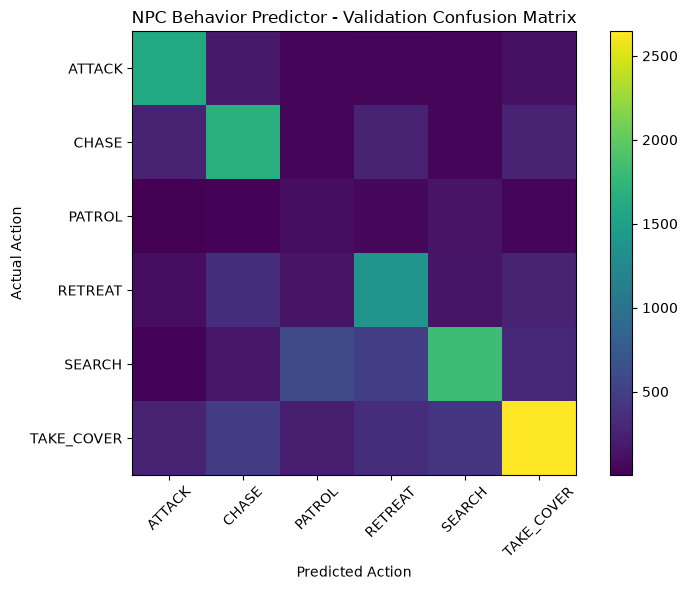

In [32]:
plt.figure(figsize=(8, 6))
plt.imshow(cm)

plt.xticks(range(len(baseline_model.classes_)), baseline_model.classes_, rotation=45)

plt.yticks(range(len(baseline_model.classes_)), baseline_model.classes_)

plt.xlabel("Predicted Action")
plt.ylabel("Actual Action")
plt.title("NPC Behavior Predictor - Validation Confusion Matrix")
plt.colorbar()
plt.tight_layout()
plt.show()

In [33]:
#saving baseline model
joblib.dump(baseline_model, r"C:\Users\lanaa\Downloads\baseline_model")

['C:\\Users\\lanaa\\Downloads\\baseline_model']

2-RANDOM FOREST

In [34]:
from sklearn.ensemble import RandomForestClassifier

In [35]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

In [36]:
rf_model.fit(x_train_processed, y_train)
y_val_rf_pred = rf_model.predict(x_val_processed)

In [37]:
rf_accuracy = accuracy_score(y_val, y_val_rf_pred)
rf_macro_f1 = f1_score(y_val, y_val_rf_pred, average='macro')

In [38]:
print("Random Forest Validation Accuracy:", rf_accuracy)
print("Random Forest Validation Macro F1:", rf_macro_f1)

Random Forest Validation Accuracy: 0.6686319973501159
Random Forest Validation Macro F1: 0.5908922217995606


In [39]:
print(classification_report(y_val, y_val_rf_pred, digits=4))

              precision    recall  f1-score   support

      ATTACK     0.7111    0.8585    0.7779      2056
       CHASE     0.6574    0.7133    0.6842      2553
      PATROL     0.1733    0.1096    0.1343       356
     RETREAT     0.5584    0.6498    0.6006      2370
      SEARCH     0.6620    0.6892    0.6753      3401
  TAKE_COVER     0.7785    0.5928    0.6731      4359

    accuracy                         0.6686     15095
   macro avg     0.5901    0.6022    0.5909     15095
weighted avg     0.6738    0.6686    0.6657     15095



In [55]:
# Comparing Random Forest with the Logistic Regression
model_comparison = pd.DataFrame({
    "Model" : [
        "Logistic Regression",
        "Random Forest"
    ],
    "Validation Accuracy" : [
        lr_accuracy,
        rf_accuracy
    ],
    "Validation Macro F1": [
        lr_macro_f1,
        rf_macro_f1
    ]
})

model_comparison

,Model,Validation Accuracy,Validation Macro F1
0,Logistic Regression,0.610533,0.552729
1,Random Forest,0.668632,0.590892


In [57]:
# saving the model
joblib.dump(rf_model, r"C:\Users\lanaa\Downloads\random_forest.joblib")

['C:\\Users\\lanaa\\Downloads\\random_forest.joblib']

3- XGBoost Model

In [61]:
from xgboost import XGBClassifier

In [73]:
xgb_model = XGBClassifier(
    n_estimators = 300,
    max_depth = 6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softprob',
    eval_metric='mlogloss',
    n_jobs=-1
)

In [67]:
## XGBClassifier doesn't accept string labels so we have to encode the target labels

In [68]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

In [69]:
y_train_xgb = label_encoder.fit_transform(y_train)
y_val_xgb = label_encoder.transform(y_val)

In [70]:
print("Encode classes:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i,'=', class_name)

Encode classes:
0 = ATTACK
1 = CHASE
2 = PATROL
3 = RETREAT
4 = SEARCH
5 = TAKE_COVER


In [74]:
xgb_model.fit(x_train_processed, y_train_xgb)

,"objective objective: typing.Union[str, xgboost.objective.Objective, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn

In [77]:
y_val_xgb_encoded = xgb_model.predict(x_val_processed)

In [80]:
## now we return the prediction back to the original action(target) name
y_val_xgb_pred = label_encoder.inverse_transform(y_val_xgb_encoded.astype(int))

In [82]:
y_val_xgb_pred

array(['RETREAT', 'RETREAT', 'TAKE_COVER', ..., 'ATTACK', 'ATTACK',
       'ATTACK'], shape=(15095,), dtype=object)

In [83]:
xgb_accuracy = accuracy_score(y_val, y_val_xgb_pred)

In [84]:
print("XGBoost Accuracy:", xgb_accuracy)

XGBoost Accuracy: 0.6974494865849619


In [85]:
xgb_macro_f1 = f1_score(
    y_val,
    y_val_xgb_pred,
    average='macro'
)

In [86]:
print("XGBoost Macro F1:", xgb_macro_f1)

XGBoost Macro F1: 0.589798002366545


In [87]:
print(classification_report(
    y_val,
    y_val_xgb_pred,
    digits=4
))

              precision    recall  f1-score   support

      ATTACK     0.7848    0.8264    0.8050      2056
       CHASE     0.7110    0.7094    0.7102      2553
      PATROL     0.0000    0.0000    0.0000       356
     RETREAT     0.6078    0.6211    0.6144      2370
      SEARCH     0.6670    0.7251    0.6948      3401
  TAKE_COVER     0.7223    0.7066    0.7144      4359

    accuracy                         0.6974     15095
   macro avg     0.5822    0.5981    0.5898     15095
weighted avg     0.6814    0.6974    0.6891     15095



C:\Users\lanaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lanaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\lanaa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_clas

COMPARISON BETWEEN THE THREE MODELS THAT WE TESTED

In [89]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Macro F1": [
        lr_macro_f1,
        rf_macro_f1,
        xgb_macro_f1
    ]
})
model_comparison

,Model,Accuracy,Macro F1
0,Logistic Regression,0.610533,0.552729
1,Random Forest,0.668632,0.590892
2,XGBoost,0.697449,0.589798


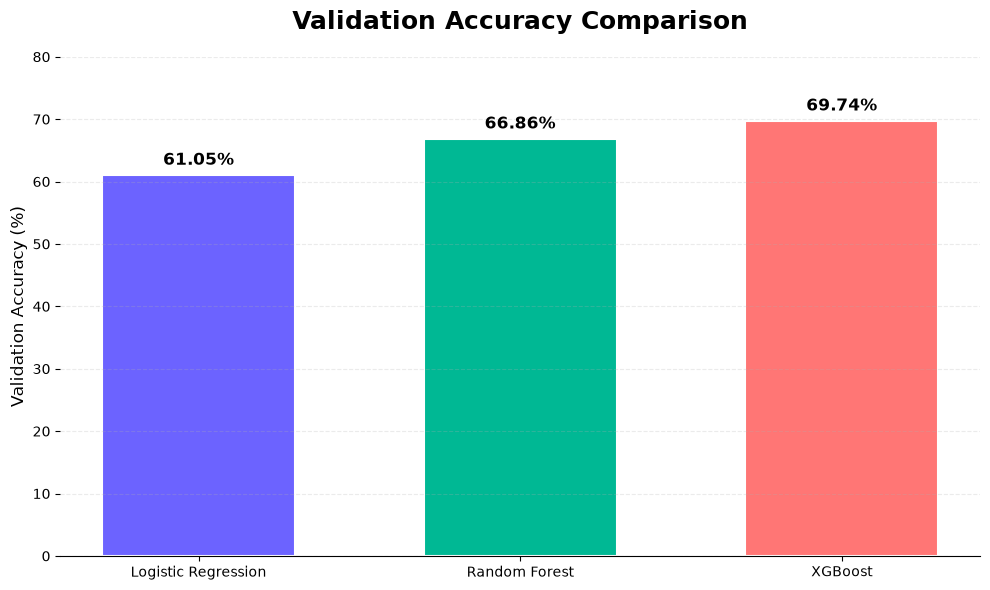

In [99]:
models = model_comparison["Model"]
accuracy = model_comparison["Accuracy"] * 100

# Colors for each model
colors = ["#6C63FF", "#00B894", "#FF7675"]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    models,
    accuracy,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

# Add percentage labels
for bar, value in zip(bars, accuracy):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_title("Validation Accuracy Comparison",fontsize=18,fontweight="bold",pad=20)
ax.set_ylabel("Validation Accuracy (%)",fontsize=12)
ax.set_ylim(0, 80)
ax.grid(axis="y",linestyle="--",alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()

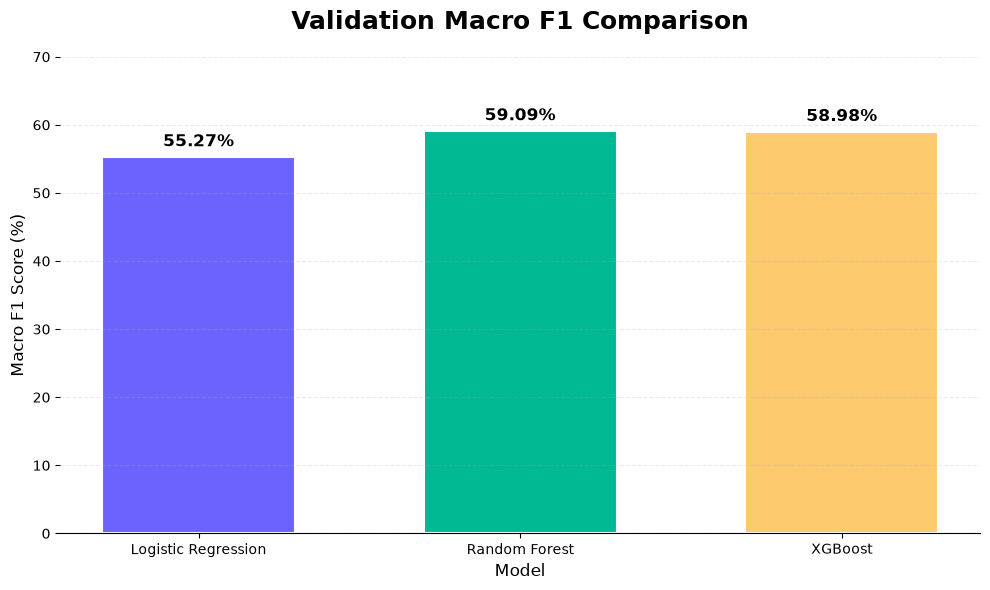

In [109]:
models = model_comparison["Model"]
macro_f1 = model_comparison["Macro F1"] * 100

colors = ["#6C63FF", "#00B894", "#FDCB6E"]

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    models,
    macro_f1,
    color=colors,
    width=0.6,
    edgecolor="white",
    linewidth=1.5
)

for bar, value in zip(bars, macro_f1):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{value:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

ax.set_title("Validation Macro F1 Comparison",fontsize=18,fontweight="bold",pad=20)
ax.set_ylabel("Macro F1 Score (%)",fontsize=12)
ax.set_xlabel("Model",fontsize=12)

ax.set_ylim(0, 70)
ax.grid(axis="y",linestyle="--",alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.show()